In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/Q1b_NER.csv")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

SEED = 2026
N_SETS = 10
SWAPS_PER_EDGE = 10           # attempted swaps = SWAPS_PER_EDGE x (number of 1s in the matrix)
N_CHECKPOINTS = 40            # how often to record the mixing diagnostic
SAVE_RANDOM_CUISINES = False  # True -> write all 10 random cuisines to CSV (~25 MB total)

ORIG_COLOR, RAND_COLOR, CONTRAST_COLOR = "#2a78d6", "#eb6834", "#8a8a8a"
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

In [12]:
def load_recipes(path):
    raw = pd.read_csv(path)
    missing_cols = {"Recipe_ID", "Ingredient_Name"} - set(raw.columns)
    if missing_cols:
        raise ValueError(f"Missing columns in {path}: {missing_cols}")
    df = raw[["Recipe_ID", "Ingredient_Name"]].dropna().copy()
    df["Ingredient_Name"] = df["Ingredient_Name"].astype(str).str.strip().str.lower()
    df = df[df["Ingredient_Name"] != ""]
    recipes = (df.groupby("Recipe_ID", sort=True)["Ingredient_Name"]
                 .agg(lambda s: tuple(sorted(set(s)))))
    return recipes[recipes.map(len) > 0]


recipes = load_recipes(DATA_PATH)
recipe_ids = recipes.index.to_numpy()
ingredients = np.array(sorted({i for r in recipes for i in r}))
ing_index = {name: j for j, name in enumerate(ingredients)}
N, U = len(recipes), len(ingredients)

orig_rows = [frozenset(ing_index[i] for i in r) for r in recipes]   # recipe -> ingredient ids


def row_sums(rows):
    return np.array([len(r) for r in rows])


def col_sums(rows, n_cols):
    return np.bincount(np.fromiter((i for r in rows for i in r), dtype=np.int64), minlength=n_cols)


orig_sizes = row_sums(orig_rows)
orig_freq = col_sums(orig_rows, U)
E = int(orig_sizes.sum())
assert E == orig_freq.sum()
print(f"Recipes N = {N:,}, ingredients U = {U:,}, edges (1s in M) E = {E:,}")
print(f"Matrix density = {E / (N * U):.5f}")
print(f"Ingredients used in only one recipe: {(orig_freq == 1).sum():,} ({(orig_freq == 1).mean():.1%})")

Recipes N = 9,988, ingredients U = 12,641, edges (1s in M) E = 99,874
Matrix density = 0.00079
Ingredients used in only one recipe: 8,571 (67.8%)


In [3]:
def double_edge_swap(rows, n_attempts, rng, n_checkpoints=0, reference=None):
    """Randomise a binary incidence matrix while keeping row sums and column sums exactly.

    rows      : list of sets of column ids (one per recipe)
    returns   : (new_rows, n_successful_swaps, trace) where trace = [(attempts, fraction of
                reference edges still present), ...] when n_checkpoints > 0
    """
    R = [set(r) for r in rows]
    edge_r = [r for r, cols in enumerate(R) for _ in cols]
    edge_i = [i for cols in R for i in cols]
    n_edges = len(edge_r)

    def overlap():
        return sum(1 for r, i in zip(edge_r, edge_i) if i in reference[r]) / n_edges

    trace = [(0, overlap())] if n_checkpoints else []
    chunk = max(1, n_attempts // max(1, n_checkpoints))
    done, n_swaps = 0, 0
    while done < n_attempts:
        m = min(chunk, n_attempts - done)
        picks = rng.integers(0, n_edges, size=(m, 2)).tolist()
        for a, b in picks:
            r1, i1, r2, i2 = edge_r[a], edge_i[a], edge_r[b], edge_i[b]
            if r1 == r2 or i1 == i2:            # same recipe or same ingredient
                continue
            if i2 in R[r1] or i1 in R[r2]:      # would create a duplicate ingredient
                continue
            R[r1].remove(i1); R[r1].add(i2)
            R[r2].remove(i2); R[r2].add(i1)
            edge_i[a], edge_i[b] = i2, i1
            n_swaps += 1
        done += m
        if n_checkpoints:
            trace.append((done, overlap()))
    return R, n_swaps, trace


# expected chance-level overlap with the original (used as a reference line)
chance_overlap = np.mean([min(1.0, orig_sizes[r] * orig_freq[i] / E)
                          for r, row in enumerate(orig_rows) for i in row])
print(f"Expected overlap with the original by chance ≈ {chance_overlap:.3f}")

Expected overlap with the original by chance ≈ 0.053


In [4]:
n_attempts = SWAPS_PER_EDGE * E
child_seeds = np.random.SeedSequence(SEED).spawn(N_SETS)
random_sets, summaries, traces = [], [], []
for k, seed in enumerate(child_seeds, start=1):
    rows_k, n_swaps, trace = double_edge_swap(orig_rows, n_attempts, np.random.default_rng(seed),
                                              n_checkpoints=N_CHECKPOINTS, reference=orig_rows)
    random_sets.append(rows_k)
    traces.append(trace)
    summaries.append({"Set": k, "Attempted_swaps": n_attempts, "Successful_swaps": n_swaps,
                      "Acceptance_rate": n_swaps / n_attempts, "Edges_kept_from_original": trace[-1][1]})
    print(f"Set {k:>2}: {n_swaps:,} / {n_attempts:,} swaps accepted; "
          f"fraction of original edges kept = {trace[-1][1]:.3f}")

Set  1: 901,757 / 998,740 swaps accepted; fraction of original edges kept = 0.053
Set  2: 901,225 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set  3: 901,738 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set  4: 901,640 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set  5: 901,595 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set  6: 901,506 / 998,740 swaps accepted; fraction of original edges kept = 0.053
Set  7: 901,876 / 998,740 swaps accepted; fraction of original edges kept = 0.053
Set  8: 901,623 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set  9: 901,675 / 998,740 swaps accepted; fraction of original edges kept = 0.052
Set 10: 901,080 / 998,740 swaps accepted; fraction of original edges kept = 0.052


In [5]:
orig_set_of_rows = [set(r) for r in orig_rows]
for k, rows_k in enumerate(random_sets, start=1):
    assert len(rows_k) == N                                        # same number of recipes
    assert np.array_equal(row_sums(rows_k), orig_sizes)           # every recipe size preserved
    assert np.array_equal(col_sums(rows_k, U), orig_freq)         # every ingredient frequency preserved
    assert row_sums(rows_k).sum() == E                            # total occurrences unchanged
    assert all(all(0 <= i < U for i in r) for r in rows_k)        # valid ingredient ids
    # binary / no duplicates: each row is a set, and its size equals the original size
    # (a duplicate would have collapsed the set and changed the row sum)

# reproducibility: rerunning set 1 with the same seed gives the same cuisine
check_rows, _, _ = double_edge_swap(orig_rows, n_attempts, np.random.default_rng(child_seeds[0]))
assert all(a == b for a, b in zip(check_rows, random_sets[0]))

# how much did the randomisation change the cuisine?
summary = pd.DataFrame(summaries)
summary["Recipes_unchanged"] = [sum(a == b for a, b in zip(rows_k, orig_set_of_rows)) for rows_k in random_sets]
summary["Mean_Jaccard_with_original"] = [
    np.mean([len(a & b) / len(a | b) for a, b in zip(rows_k, orig_set_of_rows)]) for rows_k in random_sets]
summary["Edges_shared_with_set_1"] = [
    sum(len(a & b) for a, b in zip(rows_k, random_sets[0])) / E for rows_k in random_sets]
summary.to_csv(OUT_DIR / "Q3_randomisation_summary.csv", index=False)

print("All 10 cuisines: row sums, column sums, totals, recipe count preserved exactly; reproducible.")
summary.round(4)

All 10 cuisines: row sums, column sums, totals, recipe count preserved exactly; reproducible.


,Set,Attempted_swaps,Successful_swaps,Acceptance_rate,Edges_kept_from_original,Recipes_unchanged,Mean_Jaccard_with_original,Edges_shared_with_set_1
0,1,998740,901757,0.9029,0.0529,0,0.0247,1.0000
1,2,998740,901225,0.9024,0.0522,0,0.0243,0.0516
2,3,998740,901738,0.9029,0.0520,0,0.0244,0.0515
3,4,998740,901640,0.9028,0.0525,0,0.0245,0.0521
4,5,998740,901595,0.9027,0.0519,0,0.0239,0.0520
5,6,998740,901506,0.9026,0.0527,0,0.0246,0.0516
6,7,998740,901876,0.9030,0.0529,0,0.0245,0.0513
7,8,998740,901623,0.9028,0.0523,0,0.0242,0.0514
8,9,998740,901675,0.9028,0.0519,0,0.0241,0.0504
9,10,998740,901080,0.9022,0.0521,0,0.0240,0.0520


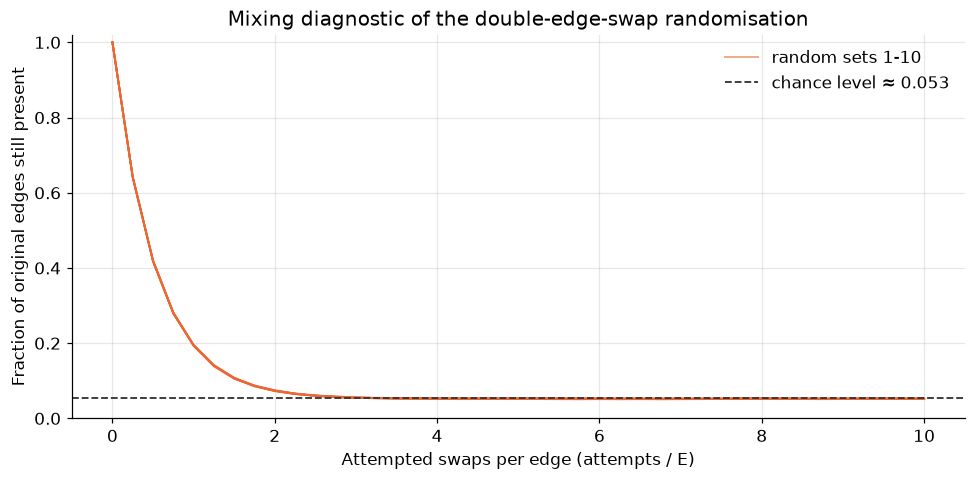

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for k, tr in enumerate(traces, start=1):
    x, y = zip(*tr)
    ax.plot(np.array(x) / E, y, color=RAND_COLOR, alpha=0.6, lw=1.2, label="random sets 1-10" if k == 1 else None)
ax.axhline(chance_overlap, color="#333333", ls="--", lw=1.2, label=f"chance level ≈ {chance_overlap:.3f}")
ax.set_xlabel("Attempted swaps per edge (attempts / E)")
ax.set_ylabel("Fraction of original edges still present")
ax.set_title("Mixing diagnostic of the double-edge-swap randomisation")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3_mixing_diagnostic.png")
plt.show()

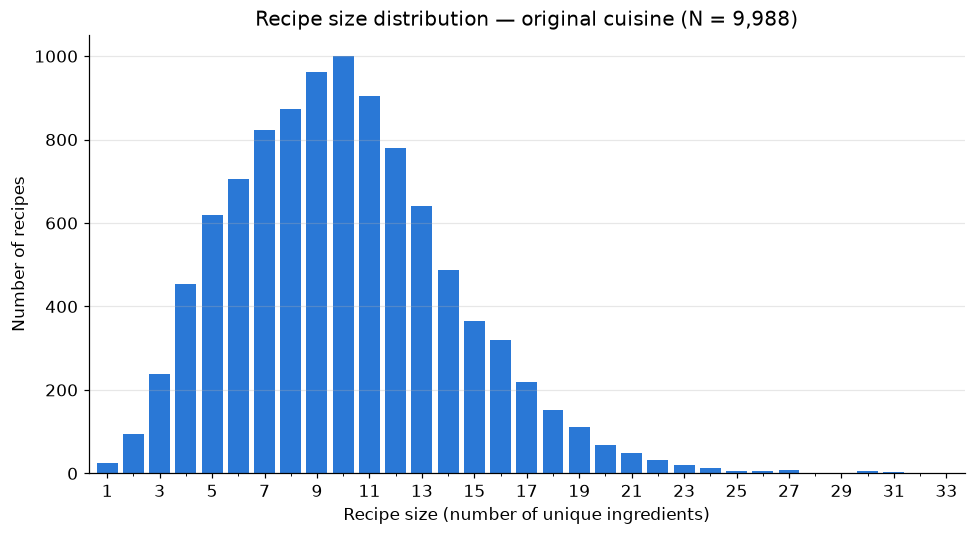

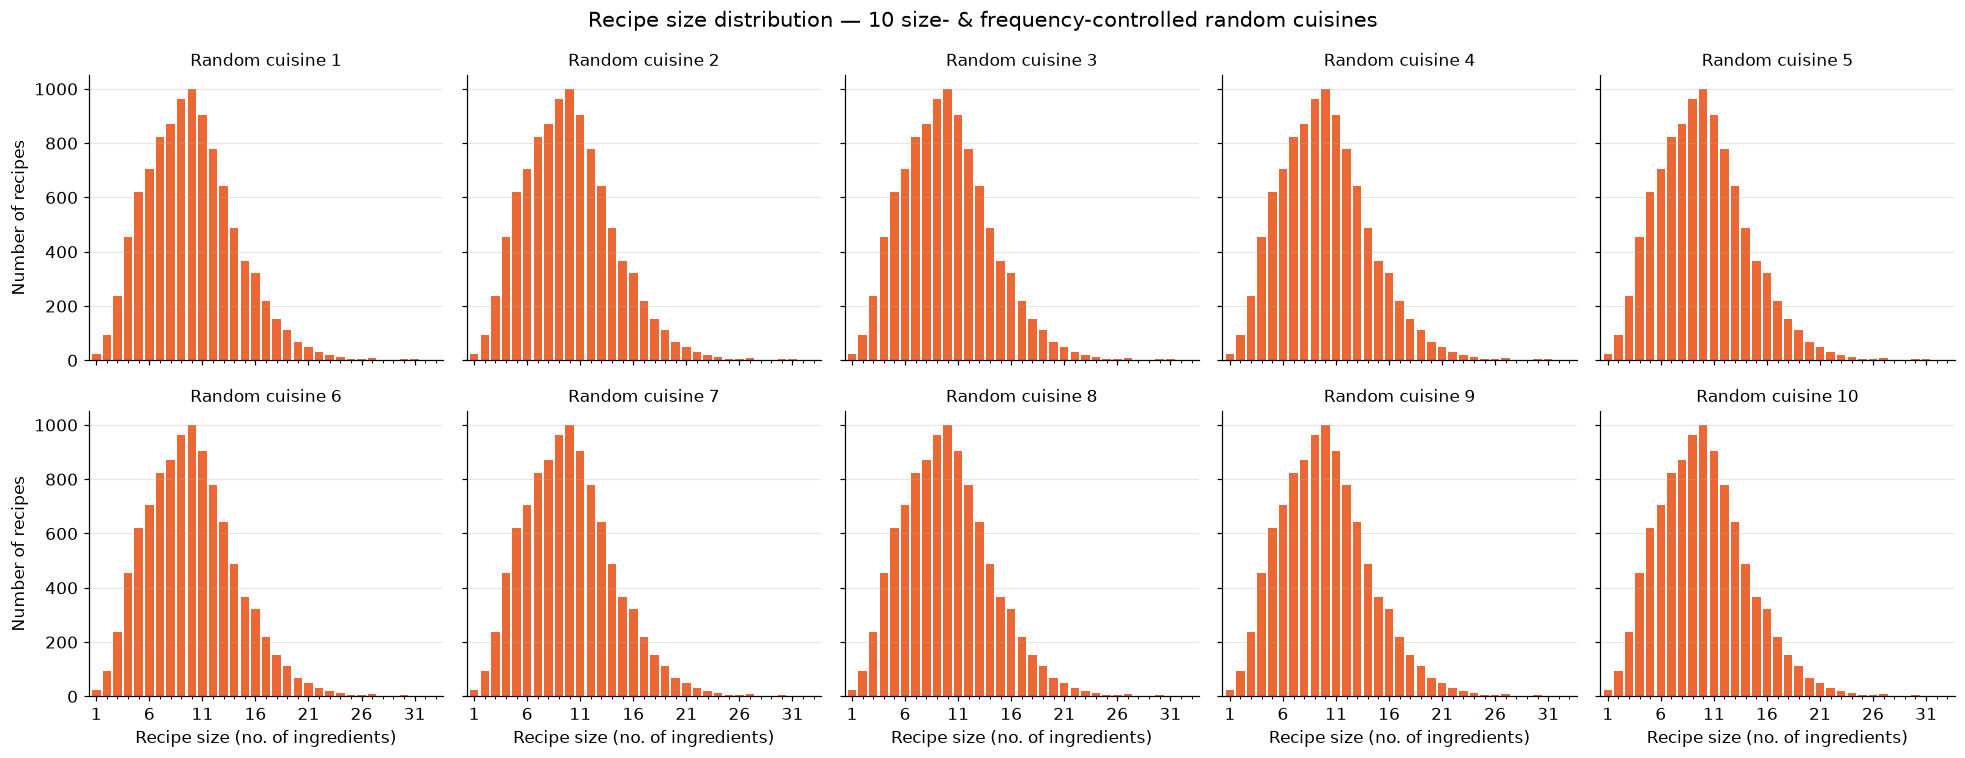

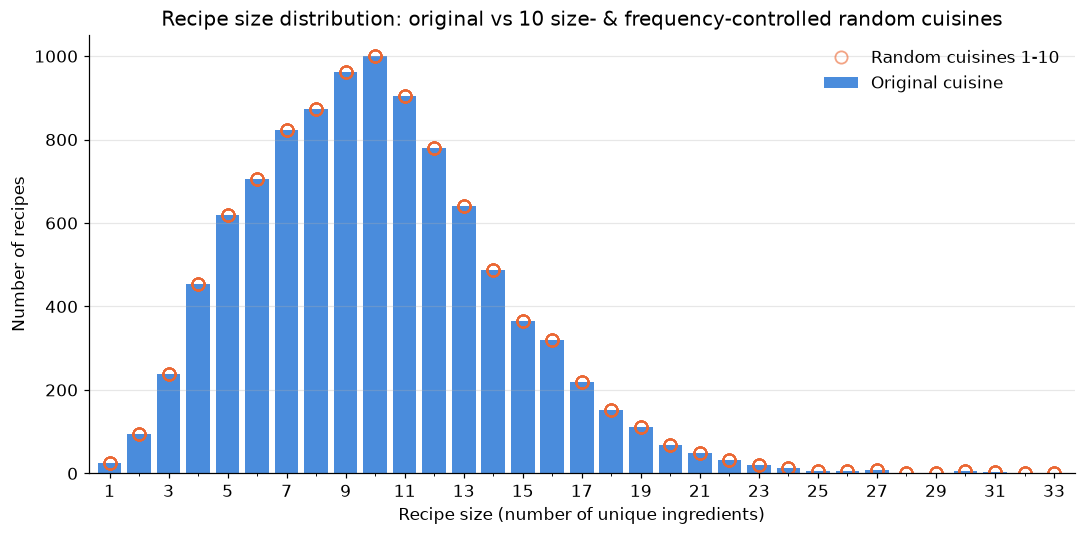

In [7]:
size_support = np.arange(1, orig_sizes.max() + 1)


def size_counts(sizes):
    return pd.Series(sizes).value_counts().reindex(size_support, fill_value=0).to_numpy()


orig_size_counts = size_counts(orig_sizes)
rand_size_counts = [size_counts(row_sums(rows_k)) for rows_k in random_sets]


def style_size_axis(ax, step=2):
    ax.set_xticks(size_support[::step])
    ax.set_xticks(size_support, minor=True)
    ax.set_xlim(0.3, size_support.max() + 0.7)
    ax.grid(axis="y", alpha=0.3)


# (i) original
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(size_support, orig_size_counts, width=0.8, color=ORIG_COLOR)
ax.set_xlabel("Recipe size (number of unique ingredients)")
ax.set_ylabel("Number of recipes")
ax.set_title(f"Recipe size distribution — original cuisine (N = {N:,})")
style_size_axis(ax)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3a_recipe_size_distribution_original.png")
plt.show()

# (ii) the 10 random cuisines, one panel each
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for k, (ax, rc) in enumerate(zip(axes.flat, rand_size_counts), start=1):
    ax.bar(size_support, rc, width=0.8, color=RAND_COLOR)
    ax.set_title(f"Random cuisine {k}", fontsize=11)
    style_size_axis(ax, step=5)
for ax in axes[1]:
    ax.set_xlabel("Recipe size (no. of ingredients)")
for ax in axes[:, 0]:
    ax.set_ylabel("Number of recipes")
fig.suptitle("Recipe size distribution — 10 size- & frequency-controlled random cuisines", fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3a_recipe_size_distribution_random.png")
plt.show()

# (iii) overlay: original vs all 10 random cuisines
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(size_support, orig_size_counts, width=0.8, color=ORIG_COLOR, alpha=0.85, label="Original cuisine")
for k, rc in enumerate(rand_size_counts, start=1):
    ax.plot(size_support, rc, "o", ms=8, mfc="none", mec=RAND_COLOR, mew=1.2, alpha=0.6,
            label="Random cuisines 1-10" if k == 1 else None)
ax.set_xlabel("Recipe size (number of unique ingredients)")
ax.set_ylabel("Number of recipes")
ax.set_title("Recipe size distribution: original vs 10 size- & frequency-controlled random cuisines")
style_size_axis(ax)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3a_recipe_size_distribution.png")
plt.show()

size_table = pd.DataFrame({"Recipe_Size": size_support, "Original": orig_size_counts})
for k, rc in enumerate(rand_size_counts, start=1):
    size_table[f"Random_Set_{k}"] = rc
size_table.to_csv(OUT_DIR / "Q3_recipe_size_counts.csv", index=False)
assert all(np.array_equal(rc, orig_size_counts) for rc in rand_size_counts)

In [8]:
def frequency_rank(freq):
    """DataFrame of ingredients ranked by descending frequency (ties: alphabetical)."""
    df = pd.DataFrame({"Ingredient": ingredients, "Frequency": freq})
    df = df.sort_values(["Frequency", "Ingredient"], ascending=[False, True], kind="mergesort")
    df["Rank"] = np.arange(1, len(df) + 1)
    return df.reset_index(drop=True)


orig_fr = frequency_rank(orig_freq)
rand_frs = [frequency_rank(col_sums(rows_k, U)) for rows_k in random_sets]

# size-only contrast (as in Q2a): uniform ingredients, same recipe sizes
rng_c = np.random.default_rng(np.random.SeedSequence(SEED).spawn(N_SETS + 1)[-1])
uniform_rows = [set(rng_c.choice(U, size=s, replace=False).tolist()) for s in orig_sizes]
uniform_fr = frequency_rank(col_sums(uniform_rows, U))
uniform_fr = uniform_fr[uniform_fr["Frequency"] > 0]

for fr in rand_frs:
    assert np.array_equal(fr["Frequency"].to_numpy(), orig_fr["Frequency"].to_numpy())
    assert fr["Ingredient"].tolist() == orig_fr["Ingredient"].tolist()   # same ingredient at each rank
print("Top 10 ingredients (original = every random cuisine):")
print(orig_fr.head(10).to_string(index=False))


def style_rank_axis(ax):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Rank of ingredient (1 = most frequent, log scale)")
    ax.set_ylabel("Frequency (number of recipes, log scale)")
    ax.grid(which="major", alpha=0.3)

Top 10 ingredients (original = every random cuisine):
         Ingredient  Frequency  Rank
             garlic       3104     1
          olive oil       2141     2
             butter       1817     3
        plain flour       1643     4
               eggs       1589     5
              lemon       1357     6
              onion       1152     7
golden caster sugar        962     8
       caster sugar        942     9
      vegetable oil        882    10


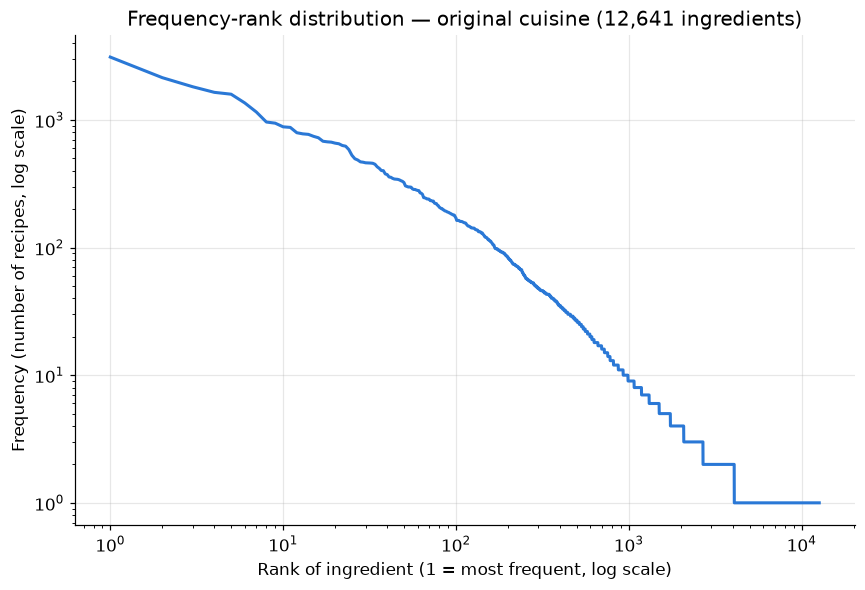

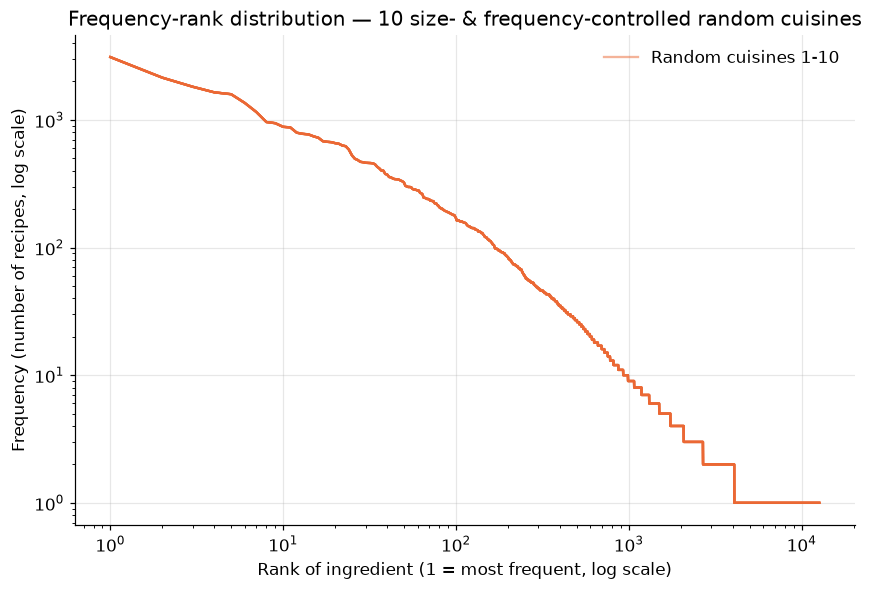

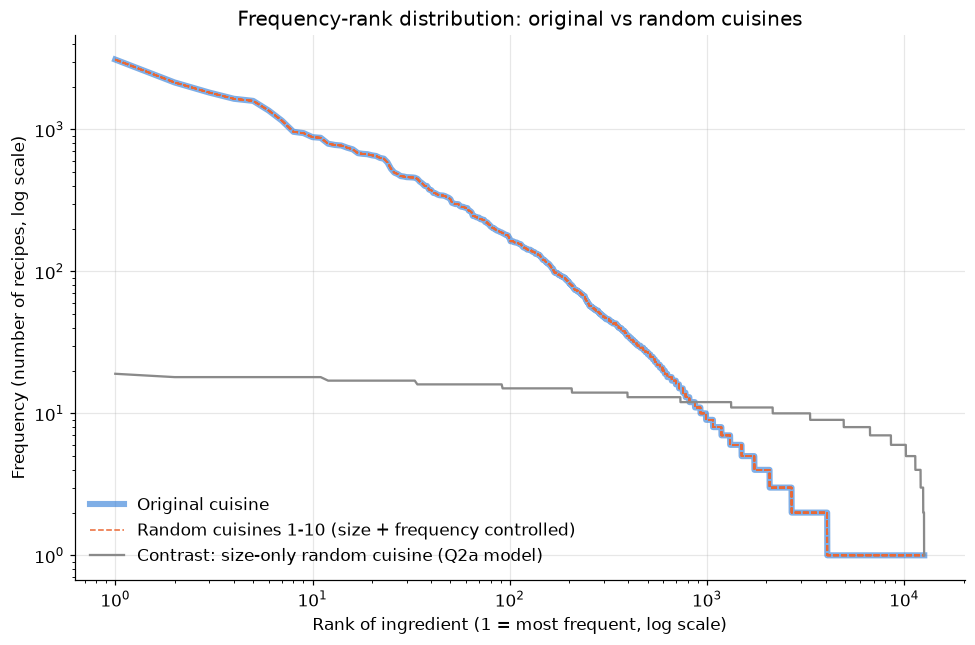

In [9]:
# (i) original
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(orig_fr["Rank"], orig_fr["Frequency"], color=ORIG_COLOR, lw=2)
style_rank_axis(ax)
ax.set_title(f"Frequency-rank distribution — original cuisine ({U:,} ingredients)")
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3b_frequency_rank_original.png")
plt.show()

# (ii) 10 random cuisines
fig, ax = plt.subplots(figsize=(8, 5.5))
for k, fr in enumerate(rand_frs, start=1):
    ax.plot(fr["Rank"], fr["Frequency"], color=RAND_COLOR, lw=1.5, alpha=0.5,
            label="Random cuisines 1-10" if k == 1 else None)
style_rank_axis(ax)
ax.set_title("Frequency-rank distribution — 10 size- & frequency-controlled random cuisines")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3b_frequency_rank_random.png")
plt.show()

# (iii) overlay: original vs random (+ size-only contrast)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(orig_fr["Rank"], orig_fr["Frequency"], color=ORIG_COLOR, lw=4, alpha=0.6, label="Original cuisine")
for k, fr in enumerate(rand_frs, start=1):
    ax.plot(fr["Rank"], fr["Frequency"], color=RAND_COLOR, lw=1, ls="--",
            label="Random cuisines 1-10 (size + frequency controlled)" if k == 1 else None)
ax.plot(uniform_fr["Rank"], uniform_fr["Frequency"], color=CONTRAST_COLOR, lw=1.5,
        label="Contrast: size-only random cuisine (Q2a model)")
style_rank_axis(ax)
ax.set_title("Frequency-rank distribution: original vs random cuisines")
ax.legend(frameon=False, loc="lower left")
fig.tight_layout()
fig.savefig(OUT_DIR / "Q3b_frequency_rank_distribution.png")
plt.show()

In [10]:
fr_table = orig_fr.rename(columns={"Frequency": "Original_Frequency"})[["Rank", "Ingredient", "Original_Frequency"]]
for k, rows_k in enumerate(random_sets, start=1):
    fr_table[f"Random_Set_{k}_Frequency"] = col_sums(rows_k, U)[[ing_index[i] for i in fr_table["Ingredient"]]]
fr_table.to_csv(OUT_DIR / "Q3b_frequency_rank.csv", index=False)

if SAVE_RANDOM_CUISINES:
    rows = [(k, rid, ingredients[i]) for k, rows_k in enumerate(random_sets, start=1)
            for rid, r in zip(recipe_ids, rows_k) for i in sorted(r)]
    pd.DataFrame(rows, columns=["Set", "Recipe_ID", "Ingredient_Name"]) \
      .to_csv(OUT_DIR / "Q3_random_cuisines.csv", index=False)

for f in ["Q3a_recipe_size_distribution_original.png", "Q3a_recipe_size_distribution_random.png",
          "Q3a_recipe_size_distribution.png", "Q3b_frequency_rank_original.png",
          "Q3b_frequency_rank_random.png", "Q3b_frequency_rank_distribution.png", "Q3_mixing_diagnostic.png"]:
    assert (OUT_DIR / f).stat().st_size > 0, f
print("All Q3 plots and CSVs saved.")

All Q3 plots and CSVs saved.


In [11]:
example = int(np.argmax(orig_sizes == 6))
print(f"{recipe_ids[example]}  original : {', '.join(ingredients[sorted(orig_rows[example])])}")
for k in range(3):
    print(f"{'':>{len(recipe_ids[example])}}  random {k + 1} : {', '.join(ingredients[sorted(random_sets[k][example])])}")

Recipe 1040  original : cucumber, lemon sorbet, mint, pimm's, soda water, strawberries
             random 1 : bramley apples, garlic, lime, parmesan and crusty bread, plain flour, skinless cod fillets
             random 2 : buffalo mozzarella, flat-leaf parsley, garlic, lemon juice, orange, red onion
             random 3 : boneless and skinless pork belly, butter, carrots, chicken breasts, cucumber, litre whole milk
